# 01_inspect_etn

Prvi pregled ETN kupoprodajnih podatkov za slovenski nepremičninski projekt.

## Cilji notebooka
- naloži `POSLI`, `DELISTAVB`, `ZEMLJISCA`, `sifranti`
- preveri osnovno strukturo tabel
- preveri povezljivost prek `ID_POSLA`
- dekodira ključne šifrante
- pripravi **kandidata za clean v1 subset**:
  - **simple apartment sales**
  - 1 posel = 1 del stavbe
  - brez zemljišč
  - fokus na prodajnih cenah

## Opomba
Ta notebook je namenoma **inspekcijski**, ne še finalni ETL pipeline.
Naslednji notebook naj bo `02_build_modeling_table.ipynb`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Če kaj manjka, odkomentiraj:
# !pip install pandas pyarrow matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)


## 1) Nastavitve poti za več let (2021–2025)

Ta verzija **samodejno poišče CSV-je** za leta 2021–2025.

### Kako pripraviš datoteke
Najlažje je tako:
1. iz GitHuba prenesi ZIP-e za **2021, 2022, 2023, 2024, 2025**
2. jih **razširi**
3. vseh 20 CSV-jev daj v **eno mapo**

Primer:
- lokalno na Macu: `~/Downloads/etn_2021_2025/`
- v Colabu/Drive: `/content/drive/MyDrive/etn_2021_2025/`
- v tem okolju: `/mnt/data/`

### Pomembno
Spodaj nastavi `DATA_DIR` na mapo, kjer so tvoji CSV-ji.


In [ ]:
from pathlib import Path
import zipfile

# TU NASTAVI MAPO, kjer imaš CSV-je ali ZIP-e
# Primeri:
# DATA_DIR = Path("/mnt/data")
DATA_DIR = Path("~/Documents/ursa/nepremicnine_projekt/etn_2021_2025")
# DATA_DIR = Path.home() / "Downloads" / "etn_2021_2025"

#DATA_DIR = Path("/mnt/data")
YEARS = [2021, 2022, 2023, 2024, 2025]

print("DATA_DIR =", DATA_DIR)
print("exists   =", DATA_DIR.exists())

# Če so v mapi ZIP-i, jih po potrebi razširi
zip_files = sorted(DATA_DIR.rglob("ETN_SLO_*_KPP_*.zip"))
print("Najdeni ZIP-i:", len(zip_files))
for z in zip_files:
    out_dir = z.parent / z.stem
    if not out_dir.exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(z, "r") as zip_ref:
            zip_ref.extractall(out_dir)
        print("Extracted:", z.name, "->", out_dir)

PATTERNS = {
    "posli": "ETN_SLO_{year}_KPP_KPP_POSLI_*.csv",
    "delistavb": "ETN_SLO_{year}_KPP_KPP_DELISTAVB_*.csv",
    "zemljisca": "ETN_SLO_{year}_KPP_KPP_ZEMLJISCA_*.csv",
    "sifranti": "ETN_SLO_{year}_KPP_sifranti_*.csv",
}

def find_first(pattern: str):
    hits = sorted(DATA_DIR.rglob(pattern))
    return hits[0] if hits else None

FILE_INDEX = {}
for year in YEARS:
    FILE_INDEX[year] = {kind: find_first(pat.format(year=year)) for kind, pat in PATTERNS.items()}

for year, files in FILE_INDEX.items():
    print(f"\n===== {year} =====")
    for kind, path in files.items():
        print(f"{kind:10s} -> {path}")


DATA_DIR = /content/drive/MyDrive/etn_2021_2025
exists   = True
Najdeni ZIP-i: 0

===== 2021 =====
posli      -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_KPP_POSLI_20260222.csv
delistavb  -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_KPP_DELISTAVB_20260222.csv
zemljisca  -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_KPP_ZEMLJISCA_20260222.csv
sifranti   -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2021_KPP_sifranti_20260222.csv

===== 2022 =====
posli      -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_KPP_POSLI_20260222.csv
delistavb  -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_KPP_DELISTAVB_20260222.csv
zemljisca  -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_KPP_ZEMLJISCA_20260222.csv
sifranti   -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2022_KPP_sifranti_20260222.csv

===== 2023 =====
posli      -> /content/drive/MyDrive/etn_2021_2025/ETN_SLO_2023_KPP_KPP_POSLI_20260222.csv
delistavb  -> /content/drive/MyD

## 2) Helper funkcije

In [ ]:
def load_csv(path: Path, parse_dates=None):
    df = pd.read_csv(path)
    if parse_dates:
        for col in parse_dates:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], format="%d.%m.%Y", errors="coerce")
    return df

def quick_profile(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head(3))
    print("\nmissingness (%):")
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    display(miss.head(15).round(2))

def value_counts_with_share(s: pd.Series, top_n=15):
    vc = s.value_counts(dropna=False).head(top_n)
    share = (vc / len(s) * 100).round(2)
    return pd.DataFrame({"count": vc, "share_%": share})

def make_decoder(sifranti_df: pd.DataFrame, sifrant_name: str):
    sub = sifranti_df[sifranti_df["SIFRANT"].eq(sifrant_name)].copy()
    sub = sub.dropna(subset=["NUMERICNA_VREDNOST", "OPIS"])
    return dict(zip(sub["NUMERICNA_VREDNOST"], sub["OPIS"]))

def add_decoded_column(df: pd.DataFrame, col: str, mapping: dict, new_col=None):
    new_col = new_col or f"{col}_OPIS"
    out = df.copy()
    out[new_col] = out[col].map(mapping)
    return out

def show_join_coverage(left: pd.DataFrame, right: pd.DataFrame, key="ID_POSLA", left_name="left", right_name="right"):
    left_ids = set(left[key].dropna().unique())
    right_ids = set(right[key].dropna().unique())
    inter = left_ids & right_ids
    stats = pd.DataFrame({
        "dataset": [left_name, right_name, "intersection"],
        "unique_ids": [len(left_ids), len(right_ids), len(inter)]
    })
    stats["share_vs_left_%"] = [100.0, len(inter)/max(len(left_ids),1)*100, len(inter)/max(len(left_ids),1)*100]
    stats["share_vs_right_%"] = [len(inter)/max(len(right_ids),1)*100, 100.0, len(inter)/max(len(right_ids),1)*100]
    return stats

def choose_area(row):
    for col in ["PRODANA_POVRSINA", "POVRSINA_DELA_STAVBE", "UPORABNA_POVRSINA"]:
        val = row.get(col)
        if pd.notna(val) and val > 0:
            return val
    return np.nan

def area_source(row):
    for col in ["PRODANA_POVRSINA", "POVRSINA_DELA_STAVBE", "UPORABNA_POVRSINA"]:
        val = row.get(col)
        if pd.notna(val) and val > 0:
            return col
    return np.nan


## 3) Naloži tabele za leta 2021–2025

Spodnja celica:
- naloži vsako leto posebej,
- doda stolpec `SOURCE_YEAR`,
- nato vse skupaj združi v 3 velike tabele:
  - `posli`
  - `deli`
  - `zem`
- `sifranti` pa združi in odstrani duplikate.


In [ ]:
DATE_COLS_POSLI = [
    "DATUM_UVELJAVITVE",
    "DATUM_SKLENITVE_POGODBE",
    "DATUM_ZADNJE_SPREMEMBE_POSLA",
    "DATUM_ZADNJE_UVELJAVITVE_POSLA",
    "DATUM_IZTEKA_LIZINGA",
    "DATUM_PRENEHANJA_LIZINGA",
]

posli_parts = []
deli_parts = []
zem_parts = []
sifranti_parts = []

for year in YEARS:
    files = FILE_INDEX[year]
    missing = [k for k, v in files.items() if v is None]
    if missing:
        print(f"Preskakujem {year}, ker manjkajo: {missing}")
        continue

    posli_y = load_csv(files["posli"], parse_dates=DATE_COLS_POSLI)
    deli_y = load_csv(files["delistavb"])
    zem_y = load_csv(files["zemljisca"])
    sifr_y = load_csv(files["sifranti"])

    posli_y["SOURCE_YEAR"] = year
    deli_y["SOURCE_YEAR"] = year
    zem_y["SOURCE_YEAR"] = year
    sifr_y["SOURCE_YEAR"] = year

    posli_parts.append(posli_y)
    deli_parts.append(deli_y)
    zem_parts.append(zem_y)
    sifranti_parts.append(sifr_y)

    print(f"Naloženo leto {year}: POSLI={posli_y.shape}, DELI={deli_y.shape}, ZEM={zem_y.shape}, SIFRANTI={sifr_y.shape}")

if not posli_parts:
    raise ValueError(
        "Ni bilo naloženih nobenih let. Preveri DATA_DIR in ali so datoteke pravilno poimenovane."
    )

posli = pd.concat(posli_parts, ignore_index=True)
deli = pd.concat(deli_parts, ignore_index=True)
zem = pd.concat(zem_parts, ignore_index=True)
sifranti = (
    pd.concat(sifranti_parts, ignore_index=True)
    .drop_duplicates()
    .reset_index(drop=True)
)

quick_profile(posli, "POSLI (2021–2025 skupaj)")
quick_profile(deli, "DELISTAVB (2021–2025 skupaj)")
quick_profile(zem, "ZEMLJISCA (2021–2025 skupaj)")
quick_profile(sifranti, "SIFRANTI (združeni)")


Naloženo leto 2021: POSLI=(37114, 17), DELI=(33753, 40), ZEM=(68942, 17), SIFRANTI=(353, 5)
Naloženo leto 2022: POSLI=(37347, 17), DELI=(33396, 40), ZEM=(71691, 17), SIFRANTI=(353, 5)
Naloženo leto 2023: POSLI=(31257, 17), DELI=(27512, 40), ZEM=(62070, 17), SIFRANTI=(353, 5)
Naloženo leto 2024: POSLI=(25498, 17), DELI=(23768, 40), ZEM=(46717, 17), SIFRANTI=(353, 5)
Naloženo leto 2025: POSLI=(31003, 17), DELI=(27590, 40), ZEM=(60067, 17), SIFRANTI=(353, 5)

=== POSLI (2021–2025 skupaj) ===
shape: (162219, 17)
columns: ['ID_POSLA', 'VRSTA_KUPOPRODAJNEGA_POSLA', 'DATUM_UVELJAVITVE', 'DATUM_SKLENITVE_POGODBE', 'POGODBENA_CENA_ODSKODNINA', 'VKLJUCENOST_DDV', 'STOPNJA_DDV', 'DATUM_IZTEKA_LIZINGA', 'DATUM_PRENEHANJA_LIZINGA', 'OPOMBE_O_PRAVNEM_POSLU', 'POSREDOVANJE_NEPREMICNINSKE_AGENCIJE', 'DATUM_ZADNJE_SPREMEMBE_POSLA', 'DATUM_ZADNJE_UVELJAVITVE_POSLA', 'VRSTA_AKTA', 'TRZNOST_POSLA', 'LETO', 'SOURCE_YEAR']


,ID_POSLA,VRSTA_KUPOPRODAJNEGA_POSLA,DATUM_UVELJAVITVE,DATUM_SKLENITVE_POGODBE,POGODBENA_CENA_ODSKODNINA,VKLJUCENOST_DDV,STOPNJA_DDV,DATUM_IZTEKA_LIZINGA,DATUM_PRENEHANJA_LIZINGA,OPOMBE_O_PRAVNEM_POSLU,POSREDOVANJE_NEPREMICNINSKE_AGENCIJE,DATUM_ZADNJE_SPREMEMBE_POSLA,DATUM_ZADNJE_UVELJAVITVE_POSLA,VRSTA_AKTA,TRZNOST_POSLA,LETO,SOURCE_YEAR
0,431082,1,2019-06-17,2019-04-23,NaN,0,NaN,NaT,NaT,"Ni katastrskega vpisa. Prodaja se stanovanje št. 31, v velikosti 128,1 m2 v 9. nadstropju stavbe št. 1038 na parc. ...",0.0,2025-04-15,2021-03-01,1,2.0,2021,2021
1,528114,1,2021-02-11,2021-01-19,83500.0,0,NaN,NaT,NaT,NaN,NaN,2025-04-15,2021-02-11,1,2.0,2021,2021
2,526924,1,2021-02-10,2010-10-16,700.0,0,NaN,NaT,NaT,NaN,NaN,2021-02-10,2021-02-10,1,4.0,2021,2021



missingness (%):


,0
DATUM_IZTEKA_LIZINGA,100.00
DATUM_PRENEHANJA_LIZINGA,100.00
POSREDOVANJE_NEPREMICNINSKE_AGENCIJE,100.00
OPOMBE_O_PRAVNEM_POSLU,98.82
STOPNJA_DDV,92.53
TRZNOST_POSLA,0.01
POGODBENA_CENA_ODSKODNINA,0.00
ID_POSLA,0.00
DATUM_SKLENITVE_POGODBE,0.00
VKLJUCENOST_DDV,0.00



=== DELISTAVB (2021–2025 skupaj) ===
shape: (146019, 40)
columns: ['ID_POSLA', 'SIFRA_KO', 'IME_KO', 'OBCINA', 'STEVILKA_STAVBE', 'STEVILKA_DELA_STAVBE', 'PARCELNA_STEVILKA_ZA_GEOLOKACIJO', 'INTERNA_OZNAKA_DELA_STAVBE', 'EVIDENTIRANOST_DELA_STAVBE', 'NASELJE', 'ULICA', 'HISNA_STEVILKA', 'DODATEK_HS', 'STEVILKA_STANOVANJA_ALI_POSLOVNEGA_PROSTORA', 'VRSTA_DELA_STAVBE', 'LETO_IZGRADNJE_DELA_STAVBE', 'STAVBA_JE_DOKONCANA', 'GRADBENA_FAZA', 'NOVOGRADNJA', 'PRODANA_POVRSINA', 'PRODANI_DELEZ_DELA_STAVBE', 'PRODANA_POVRSINA_DELA_STAVBE', 'PRODANA_UPORABNA_POVRSINA_DELA_STAVBE', 'NADSTROPJE_DELA_STAVBE', 'STEVILO_ZUNANJIH_PARKIRNIH_MEST', 'ATRIJ', 'POVRSINA_ATRIJA', 'OPOMBE_O_NEPREMICNINI', 'DEJANSKA_RABA_DELA_STAVBE', 'LEGA_DELA_STAVBE_V_STAVBI', 'STEVILO_SOB', 'POVRSINA_DELA_STAVBE', 'UPORABNA_POVRSINA', 'PROSTORI_DELA_STAVBE', 'POGODBENA_CENA_DELA_STAVBE', 'STOPNJA_DDV_DELA_STAVBE', 'E_CENTROID', 'N_CENTROID', 'LETO', 'SOURCE_YEAR']


...

,0
OPOMBE_O_NEPREMICNINI,100.00
STOPNJA_DDV_PARCELE,99.96
POGODBENA_CENA_PARCELE,99.96
VRSTA_TRAJNEGA_NASADA,99.71
STAROST_TRAJNEGA_NASADA,99.71
N_CENTROID,0.19
E_CENTROID,0.19
POVRSINA_PARCELE,0.19
OBCINA,0.05
IME_KO,0.05



=== SIFRANTI (združeni) ===
shape: (1765, 5)
columns: ['ID', 'SIFRANT', 'NUMERICNA_VREDNOST', 'OPIS', 'SOURCE_YEAR']


,ID,SIFRANT,NUMERICNA_VREDNOST,OPIS,SOURCE_YEAR
0,3,Vrsta zemljišča,1,Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje,2021
1,3,Vrsta zemljišča,2,"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposred...",2021
2,3,Vrsta zemljišča,3,"Zemljišče, na katerem je ali bo mogoče graditi stavbo in je delno komunalno opremljeno ali komunalno neopremljeno",2021



missingness (%):


,0
ID,0.0
SIFRANT,0.0
NUMERICNA_VREDNOST,0.0
OPIS,0.0
SOURCE_YEAR,0.0


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4) Osnovni sanity checks

In [ ]:
print("POSLI unique ID_POSLA:", posli["ID_POSLA"].nunique(), " / rows:", len(posli))
print("DELISTAVB unique ID_POSLA:", deli["ID_POSLA"].nunique(), " / rows:", len(deli))
print("ZEMLJISCA unique ID_POSLA:", zem["ID_POSLA"].nunique(), " / rows:", len(zem))

print("\nAli je POSLI 1 vrstica = 1 posel?")
print("duplikati ID_POSLA v POSLI:", posli["ID_POSLA"].duplicated().sum())

print("\nJoin coverage:")
display(show_join_coverage(posli, deli, key="ID_POSLA", left_name="POSLI", right_name="DELISTAVB"))
display(show_join_coverage(posli, zem, key="ID_POSLA", left_name="POSLI", right_name="ZEMLJISCA"))
display(show_join_coverage(deli, zem, key="ID_POSLA", left_name="DELISTAVB", right_name="ZEMLJISCA"))


POSLI unique ID_POSLA: 162219  / rows: 162219
DELISTAVB unique ID_POSLA: 91106  / rows: 146019
ZEMLJISCA unique ID_POSLA: 116757  / rows: 309487

Ali je POSLI 1 vrstica = 1 posel?
duplikati ID_POSLA v POSLI: 0

Join coverage:


,dataset,unique_ids,share_vs_left_%,share_vs_right_%
0,POSLI,162219,100.000000,100.0
1,DELISTAVB,91106,56.162348,100.0
2,intersection,91106,56.162348,100.0


,dataset,unique_ids,share_vs_left_%,share_vs_right_%
0,POSLI,162219,100.000000,100.0
1,ZEMLJISCA,116757,71.974923,100.0
2,intersection,116757,71.974923,100.0


,dataset,unique_ids,share_vs_left_%,share_vs_right_%
0,DELISTAVB,91106,100.000000,39.093159
1,ZEMLJISCA,116757,50.099884,100.000000
2,intersection,45644,50.099884,39.093159


## 5) Pregled šifrantov

To je zelo pomembno, ker bomo iz šifrantov brali:
- vrsto posla
- vrsto akta
- tržnost posla
- vrsto dela stavbe
- vrsto zemljišča


In [ ]:
print("Seznam šifrantov:")
display(pd.DataFrame(sorted(sifranti["SIFRANT"].dropna().unique()), columns=["SIFRANT"]))

for name in [
    "Vrsta kupoprodajnega posla",
    "Vrsta akta",
    "Tržnost posla",
    "Vrsta dela stavbe",
    "Vrsta zemljišča",
]:
    sub = sifranti[sifranti["SIFRANT"].eq(name)].copy()
    if len(sub):
        print(f"\n{name}")
        display(sub[["NUMERICNA_VREDNOST", "OPIS"]].sort_values("NUMERICNA_VREDNOST").reset_index(drop=True))


Seznam šifrantov:


,SIFRANT
0,Da/Ne
1,Državljanstvo
2,Evidentiranost dela stavbe
3,Gradbena faza
4,Mikrolokacija oddanih prostorov
5,Položaj pogodbene stranke
6,Pravno-organizacijska oblika
7,Stopnja DDV
8,Stopnja DDV za sestavine
9,Tržnost posla



Vrsta kupoprodajnega posla


,NUMERICNA_VREDNOST,OPIS
0,1,Prodaja nepremičnin na prostem trgu
1,1,Prodaja nepremičnin na prostem trgu
2,1,Prodaja nepremičnin na prostem trgu
3,1,Prodaja nepremičnin na prostem trgu
4,1,Prodaja nepremičnin na prostem trgu
5,2,Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje
6,2,Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje
7,2,Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje
8,2,Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje
9,2,Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje



Vrsta akta


...

,NUMERICNA_VREDNOST,OPIS
0,1,Tržen posel
1,1,Tržen posel
2,1,Tržen posel
3,1,Tržen posel
4,1,Tržen posel
5,2,Tržen posel – neustrezni podatki
6,2,Tržen posel – neustrezni podatki
7,2,Tržen posel – neustrezni podatki
8,2,Tržen posel – neustrezni podatki
9,2,Tržen posel – neustrezni podatki



Vrsta dela stavbe


,NUMERICNA_VREDNOST,OPIS
0,1,Stanovanjska hiša
1,1,Stanovanjska hiša
2,1,Stanovanjska hiša
3,1,Stanovanjska hiša
4,1,Stanovanjska hiša
...,...,...
70,15,Drugo
71,15,Drugo
72,15,Drugo
73,15,Drugo



Vrsta zemljišča


,NUMERICNA_VREDNOST,OPIS
0,1,Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje
1,1,Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje
2,1,Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje
3,1,Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje
4,1,Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje
5,2,"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposred..."
6,2,"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposred..."
7,2,"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposred..."
8,2,"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposred..."
9,2,"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposred..."


## 6) Dekodiraj ključne stolpce

In [ ]:
vrsta_posla_map = make_decoder(sifranti, "Vrsta kupoprodajnega posla")
vrsta_akta_map = make_decoder(sifranti, "Vrsta akta")
trznost_map = make_decoder(sifranti, "Tržnost posla")
vrsta_dela_map = make_decoder(sifranti, "Vrsta dela stavbe")
vrsta_zem_map = make_decoder(sifranti, "Vrsta zemljišča")

posli_d = posli.copy()
posli_d["VRSTA_KUPOPRODAJNEGA_POSLA_OPIS"] = posli_d["VRSTA_KUPOPRODAJNEGA_POSLA"].map(vrsta_posla_map)
posli_d["VRSTA_AKTA_OPIS"] = posli_d["VRSTA_AKTA"].map(vrsta_akta_map)
posli_d["TRZNOST_POSLA_OPIS"] = posli_d["TRZNOST_POSLA"].map(trznost_map)

deli_d = deli.copy()
deli_d["VRSTA_DELA_STAVBE_OPIS"] = deli_d["VRSTA_DELA_STAVBE"].map(vrsta_dela_map)

zem_d = zem.copy()
zem_d["VRSTA_ZEMLJISCA_OPIS"] = zem_d["VRSTA_ZEMLJISCA"].map(vrsta_zem_map)

print("POSLI – vrsta posla")
display(value_counts_with_share(posli_d["VRSTA_KUPOPRODAJNEGA_POSLA_OPIS"]))

print("\nPOSLI – vrsta akta")
display(value_counts_with_share(posli_d["VRSTA_AKTA_OPIS"]))

print("\nPOSLI – tržnost posla")
display(value_counts_with_share(posli_d["TRZNOST_POSLA_OPIS"]))

print("\nDELISTAVB – vrsta dela stavbe")
display(value_counts_with_share(deli_d["VRSTA_DELA_STAVBE_OPIS"], top_n=20))

print("\nZEMLJISCA – vrsta zemljišča")
display(value_counts_with_share(zem_d["VRSTA_ZEMLJISCA_OPIS"], top_n=20))


POSLI – vrsta posla


,count,share_%
VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,,
Prodaja nepremičnin na prostem trgu,153519,94.64
"Prodaja nepremicnin na javni dražbi ali druga oblika javne prodaje v izvršilnem postopku, prisilni poravnavi, stečaju ali stečajnem postopku",3579,2.21
Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje,3498,2.16
"Prodaja nepremičnin družinskim članom, med povezanimi fizičnimi in pravnimi osebami ali med povezanimi pravnimi osebami",1566,0.97
Finančni najem (lizing),57,0.04



POSLI – vrsta akta


,count,share_%
VRSTA_AKTA_OPIS,,
Osnovna pogodba,162219,100.0



POSLI – tržnost posla


,count,share_%
TRZNOST_POSLA_OPIS,,
Tržen posel – neustrezni podatki,83434,51.43
V preverjanju,26722,16.47
Drug posel,24259,14.95
Tržen posel,19343,11.92
Neopredeljen posel,8449,5.21
NaN,12,0.01



DELISTAVB – vrsta dela stavbe


,count,share_%
VRSTA_DELA_STAVBE_OPIS,,
Stanovanje,46982,32.18
Stanovanjska hiša,30461,20.86
Kmetijski objekt,20812,14.25
Tehnični ali pomožni prostori,11622,7.96
Garaža,10868,7.44
Parkirni prostor,9859,6.75
Drugo,4076,2.79
Pisarniški prostori,3347,2.29
Trgovski ali storitveni lokal,2364,1.62



ZEMLJISCA – vrsta zemljišča


,count,share_%
VRSTA_ZEMLJISCA_OPIS,,
"Zemljišče za kmetijsko rabo (njiva, travnik, pašnik)",121684,39.32
"Zemljišče pod stavbo ali drugo stavbi ali delu stavbe pripadajoče zemljišče (zemljišče pod stavbo, dvorišče, dovozna pot, vrt, zelenica, stanovanjski atrij in podobno)",62814,20.30
Zemljišče za gozdno rabo (gozd),56685,18.32
"Zemljišče, na katerem je ali bo mogoče graditi stavbo in je delno komunalno opremljeno ali komunalno neopremljeno",33345,10.77
Zemljišče na katerem je mogoče graditi stavbo in ima gradbeno dovoljenje,14618,4.72
"Zemljišče, na katerem je cesta ali parkirišče",10522,3.40
"Zemljišče, na katerem je mogoče graditi stavbo in je komunalno opremljeno (priključki na vodo, elektriko in neposredni dostop do dovozne poti)",4010,1.30
"Zemljišče, na katerem je ali bo mogoče graditi prometno ali energetsko infrastrukturo (cesta, plinovod in drugo)",3272,1.06
Neplodno ali vodno zemljišče ali drugo neuporabno zemljišče,1287,0.42


## 7) Cena in datum v `POSLI`

To je kandidat za **target** na nivoju posla.


In [ ]:
target_cols = [
    "ID_POSLA",
    "DATUM_SKLENITVE_POGODBE",
    "POGODBENA_CENA_ODSKODNINA",
    "VRSTA_KUPOPRODAJNEGA_POSLA",
    "VRSTA_KUPOPRODAJNEGA_POSLA_OPIS",
    "VRSTA_AKTA",
    "VRSTA_AKTA_OPIS",
    "TRZNOST_POSLA",
    "TRZNOST_POSLA_OPIS",
    "LETO",
]
display(posli_d[target_cols].head(10))

print("Cena missing %:", round(posli_d["POGODBENA_CENA_ODSKODNINA"].isna().mean() * 100, 2))
print("Cena <= 0 count:", int((posli_d["POGODBENA_CENA_ODSKODNINA"].fillna(0) <= 0).sum()))
print("Datum pogodbe missing %:", round(posli_d["DATUM_SKLENITVE_POGODBE"].isna().mean() * 100, 2))


,ID_POSLA,DATUM_SKLENITVE_POGODBE,POGODBENA_CENA_ODSKODNINA,VRSTA_KUPOPRODAJNEGA_POSLA,VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,VRSTA_AKTA,VRSTA_AKTA_OPIS,TRZNOST_POSLA,TRZNOST_POSLA_OPIS,LETO
0,431082,2019-04-23,NaN,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021
1,528114,2021-01-19,83500.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021
2,526924,2010-10-16,700.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,4.0,Neopredeljen posel,2021
3,546668,2021-06-09,130000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021
4,540878,2021-04-09,17900.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021
5,537665,2020-11-03,10000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021
6,536571,2021-03-23,145.87,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,3.0,Drug posel,2021
7,529004,2019-07-03,105325.28,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021
8,558163,2021-05-28,33500.00,3,"Prodaja nepremicnin na javni dražbi ali druga oblika javne prodaje v izvršilnem postopku, prisilni poravnavi, stečaj...",1,Osnovna pogodba,3.0,Drug posel,2021
9,553916,2021-06-21,14500.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021


Cena missing %: 0.0
Cena <= 0 count: 7
Datum pogodbe missing %: 0.0


## 8) Koliko vrstic na posel v `DELISTAVB` in `ZEMLJISCA`?

To pove, kako pogosto imamo:
- 1 posel = 1 del stavbe
- 1 posel = več delov stavbe
- 1 posel = več parcel
- mešane posle


In [ ]:
deli_per_posel = deli_d.groupby("ID_POSLA").size().rename("n_deli").reset_index()
zem_per_posel = zem_d.groupby("ID_POSLA").size().rename("n_parcel").reset_index()

display(value_counts_with_share(deli_per_posel["n_deli"], top_n=10))
display(value_counts_with_share(zem_per_posel["n_parcel"], top_n=10))


,count,share_%
n_deli,,
1,61726,67.75
2,17725,19.46
3,7148,7.85
4,2600,2.85
5,825,0.91
6,385,0.42
7,173,0.19
8,107,0.12
10,63,0.07


,count,share_%
n_parcel,,
1,64505,55.25
2,25134,21.53
3,10444,8.95
4,5379,4.61
5,2901,2.48
6,1825,1.56
7,1155,0.99
8,837,0.72
9,626,0.54


## 9) Prva konstrukcija “simple apartment sales” subseta

### Pravila za v1
- `POSLI`: prodaja na prostem trgu
- `POSLI`: osnovni akt
- `DELISTAVB`: stanovanje
- točno 1 del stavbe na `ID_POSLA`
- 0 zemljišč na `ID_POSLA`
- cena obstaja in je > 0


In [ ]:
# Najprej pripni število delov stavbe in število parcel na vsak posel
base = posli_d.merge(deli_per_posel, on="ID_POSLA", how="left").merge(zem_per_posel, on="ID_POSLA", how="left")
base["n_deli"] = base["n_deli"].fillna(0).astype(int)
base["n_parcel"] = base["n_parcel"].fillna(0).astype(int)

# Posli z natanko enim delom stavbe
one_building_id = set(base.loc[base["n_deli"].eq(1), "ID_POSLA"])
no_land_id = set(base.loc[base["n_parcel"].eq(0), "ID_POSLA"])

# Kandidatni deli stavb
deli_1 = deli_d[deli_d["ID_POSLA"].isin(one_building_id & no_land_id)].copy()

# Stanovanja: v ETN je pogosto koda 2 = stanovanje
# Tu namenoma filtriramo po OPISU, da lažje vidiš, kaj dejansko ostane.
apartment_mask = deli_1["VRSTA_DELA_STAVBE_OPIS"].astype(str).str.contains("stanovanje", case=False, na=False)
apt = deli_1[apartment_mask].copy()

# Združi s posli
apt = apt.merge(
    base[
        [
            "ID_POSLA",
            "DATUM_SKLENITVE_POGODBE",
            "POGODBENA_CENA_ODSKODNINA",
            "VRSTA_KUPOPRODAJNEGA_POSLA",
            "VRSTA_KUPOPRODAJNEGA_POSLA_OPIS",
            "VRSTA_AKTA",
            "VRSTA_AKTA_OPIS",
            "TRZNOST_POSLA",
            "TRZNOST_POSLA_OPIS",
            "LETO",
            "n_deli",
            "n_parcel",
        ]
    ],
    on="ID_POSLA",
    how="left",
)

apt.shape


(28008, 52)

In [ ]:
print("Predhodni apartment subset:", apt.shape)
display(apt.head(5))

print("\nVrsta posla:")
display(value_counts_with_share(apt["VRSTA_KUPOPRODAJNEGA_POSLA_OPIS"]))

print("\nVrsta akta:")
display(value_counts_with_share(apt["VRSTA_AKTA_OPIS"]))

print("\nTržnost:")
display(value_counts_with_share(apt["TRZNOST_POSLA_OPIS"]))


Predhodni apartment subset: (28008, 52)


,ID_POSLA,SIFRA_KO,IME_KO,OBCINA,STEVILKA_STAVBE,STEVILKA_DELA_STAVBE,PARCELNA_STEVILKA_ZA_GEOLOKACIJO,INTERNA_OZNAKA_DELA_STAVBE,EVIDENTIRANOST_DELA_STAVBE,NASELJE,ULICA,HISNA_STEVILKA,DODATEK_HS,STEVILKA_STANOVANJA_ALI_POSLOVNEGA_PROSTORA,VRSTA_DELA_STAVBE,LETO_IZGRADNJE_DELA_STAVBE,STAVBA_JE_DOKONCANA,GRADBENA_FAZA,NOVOGRADNJA,PRODANA_POVRSINA,PRODANI_DELEZ_DELA_STAVBE,PRODANA_POVRSINA_DELA_STAVBE,PRODANA_UPORABNA_POVRSINA_DELA_STAVBE,NADSTROPJE_DELA_STAVBE,STEVILO_ZUNANJIH_PARKIRNIH_MEST,ATRIJ,POVRSINA_ATRIJA,OPOMBE_O_NEPREMICNINI,DEJANSKA_RABA_DELA_STAVBE,LEGA_DELA_STAVBE_V_STAVBI,STEVILO_SOB,POVRSINA_DELA_STAVBE,UPORABNA_POVRSINA,PROSTORI_DELA_STAVBE,POGODBENA_CENA_DELA_STAVBE,STOPNJA_DDV_DELA_STAVBE,E_CENTROID,N_CENTROID,LETO_x,SOURCE_YEAR,VRSTA_DELA_STAVBE_OPIS,DATUM_SKLENITVE_POGODBE,POGODBENA_CENA_ODSKODNINA,VRSTA_KUPOPRODAJNEGA_POSLA,VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,VRSTA_AKTA,VRSTA_AKTA_OPIS,TRZNOST_POSLA,TRZNOST_POSLA_OPIS,LETO_y,n_deli,n_parcel
0,525820,1908,PODGORJE,KAMNIK,614.0,12.0,NaN,NaN,1,KAMNIK,BAKOVNIK,5.0,D,12.0,2,1965,1,NaN,NaN,30.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,29.9,25.5,bivalni prostor | klet,NaN,NaN,469375.55,118784.83,2021,2021,Stanovanje,2020-12-10,35000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0
1,532981,657,MARIBOR GRAD,MARIBOR,1999.0,13.0,NaN,NaN,1,MARIBOR,VOŠNJAKOVA ULICA,25.0,NaN,13.0,2,1950,1,NaN,NaN,57.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,56.7,45.9,bivalni prostor,NaN,NaN,550055.31,157775.43,2021,2021,Stanovanje,2021-02-24,73000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0
2,555215,659,TABOR,MARIBOR,1559.0,10.0,NaN,NaN,1,MARIBOR,PLEČNIKOVA ULICA,3.0,NaN,10.0,2,1971,1,NaN,NaN,65.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,64.8,57.8,"bivalni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,549707.36,156744.89,2021,2021,Stanovanje,2021-08-13,117000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0
3,531164,2680,NOVE JARŠE,LJUBLJANA,1021.0,3.0,NaN,NaN,1,LJUBLJANA,ŠMARTINSKA CESTA,147.0,NaN,3.0,2,2020,1,NaN,1.0,84.0,147/10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,pritličje,NaN,84.0,55.1,"bivalni prostor | garažni parkirni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,464490.81,103425.15,2021,2021,Stanovanje,2021-02-26,124415.32,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0
4,534026,2155,HRAŠE,RADOVLJICA,628.0,2.0,NaN,NaN,1,LESCE,FINŽGARJEVA ULICA,9.0,NaN,2.0,2,1947,1,NaN,NaN,98.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,pritličje,NaN,97.9,74.5,"bivalni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,434810.00,135946.75,2021,2021,Stanovanje,2021-03-18,105000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0



Vrsta posla:


,count,share_%
VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,,
Prodaja nepremičnin na prostem trgu,27026,96.49
Prodaja nepremičnin na prostovoljni javni dražbi ali druga oblika prostovoljne javne prodaje,352,1.26
"Prodaja nepremicnin na javni dražbi ali druga oblika javne prodaje v izvršilnem postopku, prisilni poravnavi, stečaju ali stečajnem postopku",350,1.25
"Prodaja nepremičnin družinskim članom, med povezanimi fizičnimi in pravnimi osebami ali med povezanimi pravnimi osebami",270,0.96
Finančni najem (lizing),10,0.04



Vrsta akta:


,count,share_%
VRSTA_AKTA_OPIS,,
Osnovna pogodba,28008,100.0



Tržnost:


,count,share_%
TRZNOST_POSLA_OPIS,,
Tržen posel – neustrezni podatki,13120,46.84
Tržen posel,7108,25.38
V preverjanju,4915,17.55
Drug posel,1755,6.27
Neopredeljen posel,1110,3.96


## 10) Strog filter za v1 subset

Če želiš hitro do bolj čiste verzije, uporabi:
- cena > 0
- `VRSTA_AKTA == 1`
- `VRSTA_KUPOPRODAJNEGA_POSLA == 1`
- `n_deli == 1`
- `n_parcel == 0`


In [ ]:
apt_v1 = apt.copy()

apt_v1 = apt_v1[
    apt_v1["POGODBENA_CENA_ODSKODNINA"].notna()
    & (apt_v1["POGODBENA_CENA_ODSKODNINA"] > 0)
    & apt_v1["VRSTA_AKTA"].eq(1)
    & apt_v1["VRSTA_KUPOPRODAJNEGA_POSLA"].eq(1)
    & apt_v1["n_deli"].eq(1)
    & apt_v1["n_parcel"].eq(0)
].copy()

apt_v1["area_m2"] = apt_v1.apply(choose_area, axis=1)
apt_v1["area_source"] = apt_v1.apply(area_source, axis=1)

apt_v1["price_per_m2"] = apt_v1["POGODBENA_CENA_ODSKODNINA"] / apt_v1["area_m2"]
apt_v1["sale_year"] = apt_v1["DATUM_SKLENITVE_POGODBE"].dt.year
apt_v1["sale_month"] = apt_v1["DATUM_SKLENITVE_POGODBE"].dt.month
apt_v1["property_age"] = apt_v1["sale_year"] - apt_v1["LETO_IZGRADNJE_DELA_STAVBE"]

print("apt_v1 shape:", apt_v1.shape)
display(apt_v1.head(5))


apt_v1 shape: (27024, 58)


,ID_POSLA,SIFRA_KO,IME_KO,OBCINA,STEVILKA_STAVBE,STEVILKA_DELA_STAVBE,PARCELNA_STEVILKA_ZA_GEOLOKACIJO,INTERNA_OZNAKA_DELA_STAVBE,EVIDENTIRANOST_DELA_STAVBE,NASELJE,ULICA,HISNA_STEVILKA,DODATEK_HS,STEVILKA_STANOVANJA_ALI_POSLOVNEGA_PROSTORA,VRSTA_DELA_STAVBE,LETO_IZGRADNJE_DELA_STAVBE,STAVBA_JE_DOKONCANA,GRADBENA_FAZA,NOVOGRADNJA,PRODANA_POVRSINA,PRODANI_DELEZ_DELA_STAVBE,PRODANA_POVRSINA_DELA_STAVBE,PRODANA_UPORABNA_POVRSINA_DELA_STAVBE,NADSTROPJE_DELA_STAVBE,STEVILO_ZUNANJIH_PARKIRNIH_MEST,ATRIJ,POVRSINA_ATRIJA,OPOMBE_O_NEPREMICNINI,DEJANSKA_RABA_DELA_STAVBE,LEGA_DELA_STAVBE_V_STAVBI,STEVILO_SOB,POVRSINA_DELA_STAVBE,UPORABNA_POVRSINA,PROSTORI_DELA_STAVBE,POGODBENA_CENA_DELA_STAVBE,STOPNJA_DDV_DELA_STAVBE,E_CENTROID,N_CENTROID,LETO_x,SOURCE_YEAR,VRSTA_DELA_STAVBE_OPIS,DATUM_SKLENITVE_POGODBE,POGODBENA_CENA_ODSKODNINA,VRSTA_KUPOPRODAJNEGA_POSLA,VRSTA_KUPOPRODAJNEGA_POSLA_OPIS,VRSTA_AKTA,VRSTA_AKTA_OPIS,TRZNOST_POSLA,TRZNOST_POSLA_OPIS,LETO_y,n_deli,n_parcel,area_m2,area_source,price_per_m2,sale_year,sale_month,property_age
0,525820,1908,PODGORJE,KAMNIK,614.0,12.0,NaN,NaN,1,KAMNIK,BAKOVNIK,5.0,D,12.0,2,1965,1,NaN,NaN,30.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,29.9,25.5,bivalni prostor | klet,NaN,NaN,469375.55,118784.83,2021,2021,Stanovanje,2020-12-10,35000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0,30.0,PRODANA_POVRSINA,1166.666667,2020,12,55
1,532981,657,MARIBOR GRAD,MARIBOR,1999.0,13.0,NaN,NaN,1,MARIBOR,VOŠNJAKOVA ULICA,25.0,NaN,13.0,2,1950,1,NaN,NaN,57.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,56.7,45.9,bivalni prostor,NaN,NaN,550055.31,157775.43,2021,2021,Stanovanje,2021-02-24,73000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0,57.0,PRODANA_POVRSINA,1280.701754,2021,2,71
2,555215,659,TABOR,MARIBOR,1559.0,10.0,NaN,NaN,1,MARIBOR,PLEČNIKOVA ULICA,3.0,NaN,10.0,2,1971,1,NaN,NaN,65.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,nadstropje,NaN,64.8,57.8,"bivalni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,549707.36,156744.89,2021,2021,Stanovanje,2021-08-13,117000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0,65.0,PRODANA_POVRSINA,1800.000000,2021,8,50
3,531164,2680,NOVE JARŠE,LJUBLJANA,1021.0,3.0,NaN,NaN,1,LJUBLJANA,ŠMARTINSKA CESTA,147.0,NaN,3.0,2,2020,1,NaN,1.0,84.0,147/10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,pritličje,NaN,84.0,55.1,"bivalni prostor | garažni parkirni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,464490.81,103425.15,2021,2021,Stanovanje,2021-02-26,124415.32,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0,84.0,PRODANA_POVRSINA,1481.134762,2021,2,1
4,534026,2155,HRAŠE,RADOVLJICA,628.0,2.0,NaN,NaN,1,LESCE,FINŽGARJEVA ULICA,9.0,NaN,2.0,2,1947,1,NaN,NaN,98.0,1/1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 - Stanovanje,pritličje,NaN,97.9,74.5,"bivalni prostor | klet | odprta terasa, balkon, loža",NaN,NaN,434810.00,135946.75,2021,2021,Stanovanje,2021-03-18,105000.00,1,Prodaja nepremičnin na prostem trgu,1,Osnovna pogodba,2.0,Tržen posel – neustrezni podatki,2021,1,0,98.0,PRODANA_POVRSINA,1071.428571,2021,3,74


## 11) Manjkajoče vrednosti in osnovni quality checks

In [ ]:
quality_cols = [
    "POGODBENA_CENA_ODSKODNINA",
    "area_m2",
    "price_per_m2",
    "LETO_IZGRADNJE_DELA_STAVBE",
    "property_age",
    "OBCINA",
    "NASELJE",
    "E_CENTROID",
    "N_CENTROID",
]

missing_report = (apt_v1[quality_cols].isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_report.to_frame("missing_%"))

display(apt_v1[quality_cols].describe(include="all").T)


,missing_%
NASELJE,0.48
price_per_m2,0.14
area_m2,0.14
N_CENTROID,0.13
E_CENTROID,0.13
OBCINA,0.03
POGODBENA_CENA_ODSKODNINA,0.00
property_age,0.00
LETO_IZGRADNJE_DELA_STAVBE,0.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
POGODBENA_CENA_ODSKODNINA,27024.0,NaN,NaN,NaN,132014.689784,84873.049439,28.0,74700.0,118000.0,170000.0,1225000.0
area_m2,26986.0,NaN,NaN,NaN,62.616182,85.9134,1.6,43.5,58.7,73.585,11520.0
price_per_m2,26986.0,NaN,NaN,NaN,2248.299116,1199.845237,0.571429,1366.511387,2046.471635,2979.407694,15205.724508
LETO_IZGRADNJE_DELA_STAVBE,27024.0,NaN,NaN,NaN,1965.647054,46.352772,1000.0,1961.0,1973.0,1983.0,2025.0
property_age,27024.0,NaN,NaN,NaN,57.032268,46.404129,-3.0,39.0,50.0,62.0,1022.0
OBCINA,27015,199,LJUBLJANA,6588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NASELJE,26893,702,LJUBLJANA,6497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E_CENTROID,26989.0,NaN,NaN,NaN,486381.052017,51079.003161,384190.99,458651.32,468782.79,529500.15,612310.98
N_CENTROID,26989.0,NaN,NaN,NaN,115803.852044,32617.331068,36370.79,101217.3,112739.87,143739.43,187751.64


## 12) Hitri outlier pregled

To še ni finalno čiščenje, samo prva orientacija.


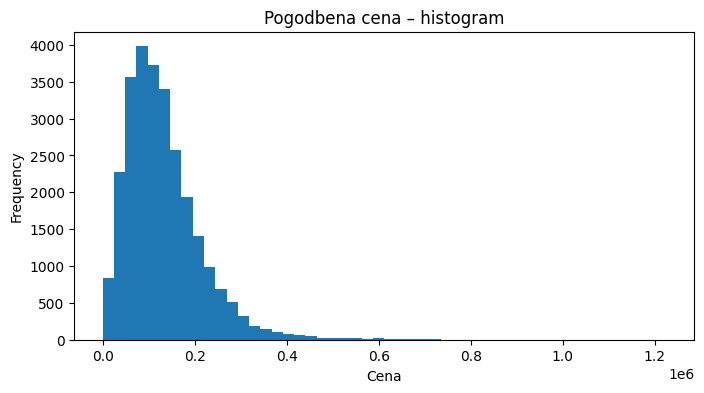

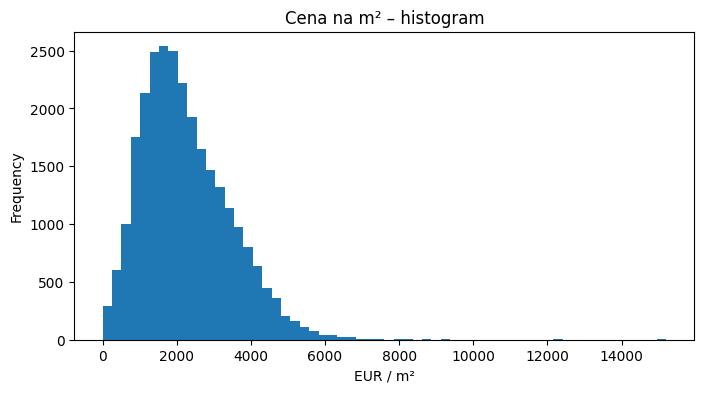

,count,mean,std,min,1%,5%,50%,95%,99%,max
POGODBENA_CENA_ODSKODNINA,27024.0,132014.689784,84873.049439,28.000000,12823.000000,30000.000000,118000.000000,280000.000000,421016.400000,1.225000e+06
area_m2,26986.0,62.616182,85.913400,1.600000,17.000000,26.000000,58.700000,109.000000,166.800000,1.152000e+04
price_per_m2,26986.0,2248.299116,1199.845237,0.571429,238.739763,641.025641,2046.471635,4409.969702,5535.859347,1.520572e+04


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
apt_v1["POGODBENA_CENA_ODSKODNINA"].dropna().plot(kind="hist", bins=50, ax=ax)
ax.set_title("Pogodbena cena – histogram")
ax.set_xlabel("Cena")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
apt_v1["price_per_m2"].replace([np.inf, -np.inf], np.nan).dropna().plot(kind="hist", bins=60, ax=ax)
ax.set_title("Cena na m² – histogram")
ax.set_xlabel("EUR / m²")
plt.show()

display(
    apt_v1[["POGODBENA_CENA_ODSKODNINA", "area_m2", "price_per_m2"]]
    .replace([np.inf, -np.inf], np.nan)
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
)


## 13) Predlog grobih filtrov za naslednji notebook

To ni nujno dokončno, je pa dober `v1` začetek.


In [ ]:
apt_v1_clean_candidate = apt_v1[
    apt_v1["area_m2"].between(15, 400, inclusive="both")
    & apt_v1["price_per_m2"].between(300, 15000, inclusive="both")
].copy()

print("Pred čiščenjem:", len(apt_v1))
print("Po grobem čiščenju:", len(apt_v1_clean_candidate))
print("Odstotek preživelih:", round(len(apt_v1_clean_candidate) / max(len(apt_v1), 1) * 100, 2), "%")

display(
    apt_v1_clean_candidate[
        [
            "ID_POSLA",
            "OBCINA",
            "NASELJE",
            "DATUM_SKLENITVE_POGODBE",
            "POGODBENA_CENA_ODSKODNINA",
            "area_m2",
            "price_per_m2",
            "LETO_IZGRADNJE_DELA_STAVBE",
            "property_age",
        ]
    ].head(10)
)


Pred čiščenjem: 27024
Po grobem čiščenju: 26463
Odstotek preživelih: 97.92 %


,ID_POSLA,OBCINA,NASELJE,DATUM_SKLENITVE_POGODBE,POGODBENA_CENA_ODSKODNINA,area_m2,price_per_m2,LETO_IZGRADNJE_DELA_STAVBE,property_age
0,525820,KAMNIK,KAMNIK,2020-12-10,35000.00,30.0,1166.666667,1965,55
1,532981,MARIBOR,MARIBOR,2021-02-24,73000.00,57.0,1280.701754,1950,71
2,555215,MARIBOR,MARIBOR,2021-08-13,117000.00,65.0,1800.000000,1971,50
3,531164,LJUBLJANA,LJUBLJANA,2021-02-26,124415.32,84.0,1481.134762,2020,1
4,534026,RADOVLJICA,LESCE,2021-03-18,105000.00,98.0,1071.428571,1947,74
5,557017,MARIBOR,MARIBOR,2021-08-16,120000.00,68.0,1764.705882,1970,51
7,551396,ROGAŠKA SLATINA,ROGAŠKA SLATINA,2021-07-01,16000.00,23.0,695.652174,1965,56
8,547156,KRANJ,KRANJ,2021-06-08,72500.00,72.0,1006.944444,1968,53
9,529986,KOBARID,KOBARID,2021-01-21,74500.00,45.0,1655.555556,2009,12
10,537858,RUŠE,BISTRICA OB DRAVI,2021-04-09,54500.00,58.0,939.655172,1961,60


## 14) Lokacija: občine in centroidi

To je pomembno za kasnejši Streamlit port iz California projekta.


In [ ]:
print("Top občine:")
display(value_counts_with_share(apt_v1_clean_candidate["OBCINA"], top_n=20))

print("\nKoliko vrstic ima koordinate?")
coords_ok = apt_v1_clean_candidate["E_CENTROID"].notna() & apt_v1_clean_candidate["N_CENTROID"].notna()
print("with coords:", int(coords_ok.sum()), "/", len(apt_v1_clean_candidate), "=", round(coords_ok.mean() * 100, 2), "%")


Top občine:


,count,share_%
OBCINA,,
LJUBLJANA,6422,24.27
MARIBOR,3646,13.78
CELJE,1256,4.75
KRANJ,980,3.70
KOPER,773,2.92
VELENJE,635,2.40
JESENICE,487,1.84
PIRAN,441,1.67
NOVO MESTO,439,1.66



Koliko vrstic ima koordinate?
with coords: 26462 / 26463 = 100.0 %


## 15) Shrani inspection outpute

To niso še finalne procesirane datoteke, ampak je uporabno za naslednji korak.


In [ ]:
OUT_DIR = Path("/mnt/data/etn_inspect_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

apt_v1.to_parquet(OUT_DIR / "apt_v1_raw.parquet", index=False)
apt_v1_clean_candidate.to_parquet(OUT_DIR / "apt_v1_clean_candidate.parquet", index=False)

summary = {
    "n_posli_rows": int(len(posli)),
    "n_posli_unique": int(posli["ID_POSLA"].nunique()),
    "n_deli_rows": int(len(deli)),
    "n_deli_unique_posli": int(deli["ID_POSLA"].nunique()),
    "n_zem_rows": int(len(zem)),
    "n_zem_unique_posli": int(zem["ID_POSLA"].nunique()),
    "n_apt_v1": int(len(apt_v1)),
    "n_apt_v1_clean_candidate": int(len(apt_v1_clean_candidate)),
}
pd.Series(summary).to_json(OUT_DIR / "inspect_summary.json", force_ascii=False, indent=2)

print("Saved to:", OUT_DIR)
print(" -", OUT_DIR / "apt_v1_raw.parquet")
print(" -", OUT_DIR / "apt_v1_clean_candidate.parquet")
print(" -", OUT_DIR / "inspect_summary.json")


Saved to: /mnt/data/etn_inspect_outputs
 - /mnt/data/etn_inspect_outputs/apt_v1_raw.parquet
 - /mnt/data/etn_inspect_outputs/apt_v1_clean_candidate.parquet
 - /mnt/data/etn_inspect_outputs/inspect_summary.json


## 16) Kaj moraš po tem notebooku vedeti

Če je vse OK, bi moral po tem notebooku znati odgovoriti:
1. Ali je `POSLI` dober vir targeta?  
2. Ali lahko sestaviš **simple apartment sales** subset?  
3. Ali imaš dovolj lokacijskih atributov za mapo in model?  
4. Kateri stolpci bodo šli v `02_build_modeling_table.ipynb`?

### Priporočen naslednji korak
Naredi `02_build_modeling_table.ipynb` in:
- zberi več let
- standardiziraj featureje
- odloči se za končni target: `log_price` ali `log_price_per_m2`
- pripravi dataset za Random Forest + LIME
